IMPORTING DEPENDENCIES

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

DATA COLLECTION AND ANALYSIS

In [147]:
#loading the data from csv file to dataframe
df = pd.read_csv(r"C:\Users\adity\medical cost\insurance.csv")

In [148]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [149]:
# no. of row and columns
df.shape

(1338, 7)

In [150]:
#some info about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


catogerical Features: Sex , Smoker , Region

In [151]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [152]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


C:\Users\adity\AppData\Local\Temp\ipykernel_22136\1021058775.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


Text(0.5, 1.0, 'AGE DISTRIBUTION')

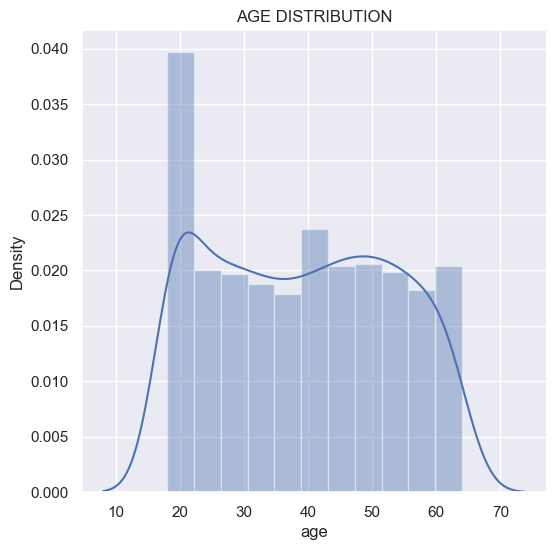

In [153]:
#AGE VALUE DISTRIBUTION
sns.set()
plt.figure(figsize = (6,6))
sns.distplot(df['age'])
plt.title('AGE DISTRIBUTION')

C:\Users\adity\AppData\Local\Temp\ipykernel_22136\4172138054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'sex' , data = df, palette=['pink','grey'])


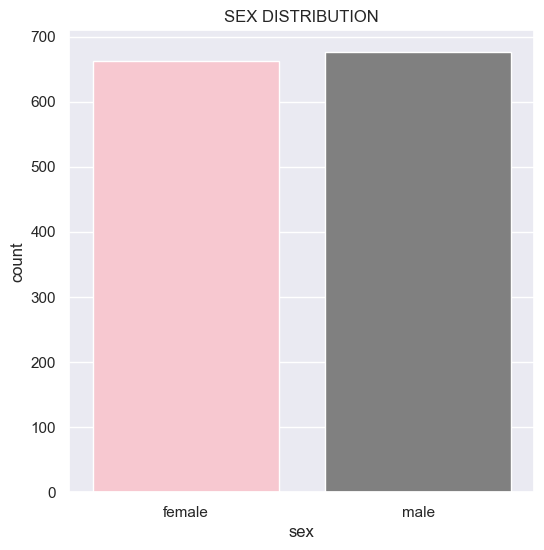

In [154]:
#GENERAL COLUMN
plt.figure(figsize = (6,6))
sns.countplot(x = 'sex' , data = df, palette=['pink','grey'])
plt.title('SEX DISTRIBUTION')
plt.show()

In [155]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

C:\Users\adity\AppData\Local\Temp\ipykernel_22136\3835371914.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


Text(0.5, 1.0, 'BMI DISTRIBUTION')

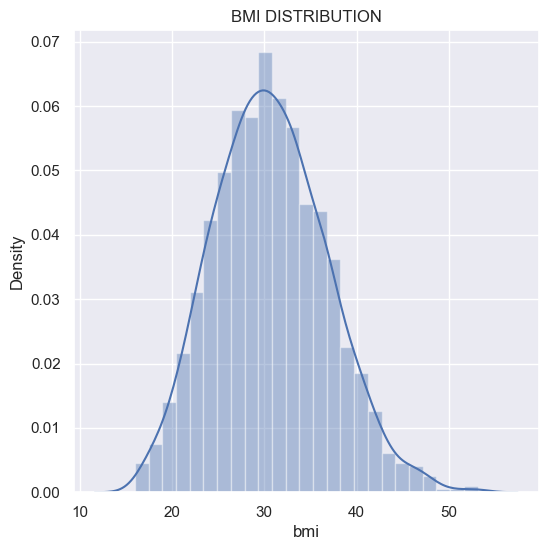

In [156]:
#BMI DISTRIBUTION
sns.set()
plt.figure(figsize = (6,6))
sns.distplot(df['bmi'])
plt.title('BMI DISTRIBUTION')

NORMAL BMI -> 18.5 to 24.9

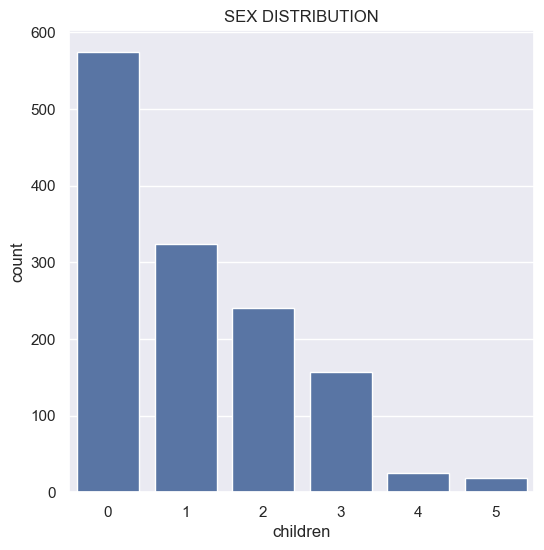

In [157]:
# CHILDREN COLUMN
plt.figure(figsize = (6,6))
sns.countplot(x = 'children' , data = df)
plt.title('SEX DISTRIBUTION')
plt.show()

In [158]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

C:\Users\adity\AppData\Local\Temp\ipykernel_22136\152704571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'smoker' , data = df, palette=['pink','grey'])


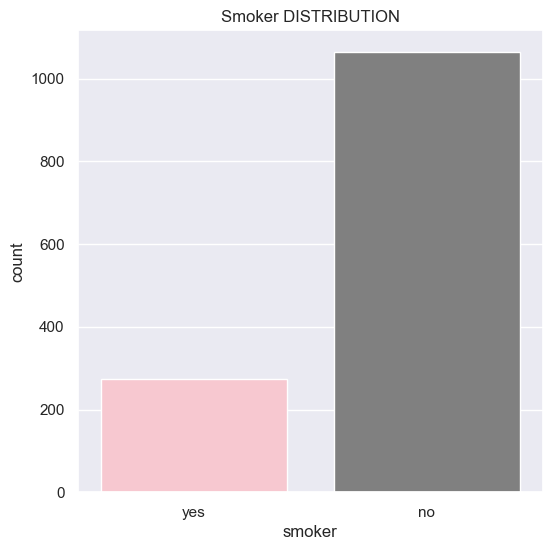

In [159]:
#SMOKER COLUMN 
plt.figure(figsize = (6,6))
sns.countplot(x = 'smoker' , data = df, palette=['pink','grey'])
plt.title('Smoker DISTRIBUTION')
plt.show()

In [160]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

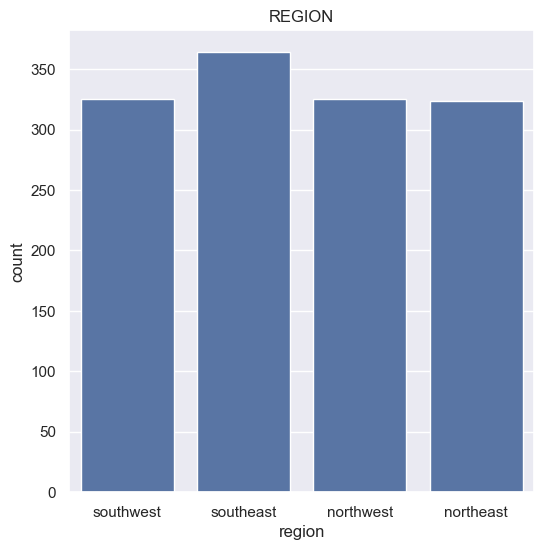

In [161]:
#REGION COLUMN
plt.figure(figsize =(6,6))
sns.countplot(x = 'region' ,data = df)
plt.title('REGION')
plt.show()

In [162]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

C:\Users\adity\AppData\Local\Temp\ipykernel_22136\2812689863.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'])


Text(0.5, 1.0, 'CHARGES DISTRIBUTION')

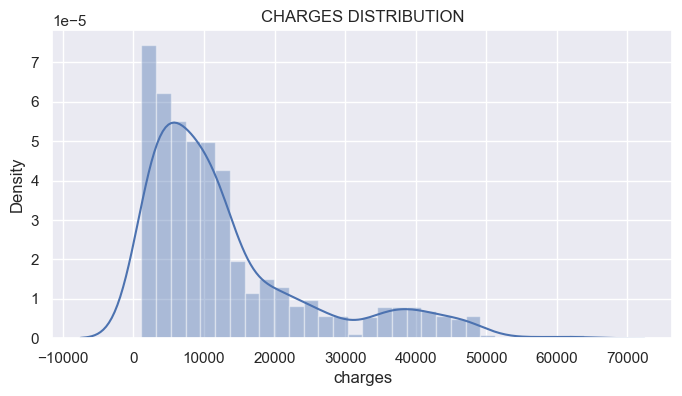

In [163]:
# DISTRIBUTION OF CHARGES
sns.set()
plt.figure(figsize = (8,4))
sns.distplot(df['charges'])
plt.title('CHARGES DISTRIBUTION')

 DATA PREPRPCESSING -->
 ENCODING CATEGORICAL DATA 

In [177]:
#encoding sex column
df.replace({'sex':{'male':0 ,'female':1}},inplace= True)
#encoding smoker column
df.replace({'smoker':{'no':0, 'yes':1}}, inplace=True)
#encoding region column 
df.replace({'region':{'southeast':0, 'southwest':1, 'northeast':2, 'northwest':3}}, inplace=True)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,3,21984.47061
4,32,0,28.880,0,0,3,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,3,10600.54830
1334,18,1,31.920,0,0,2,2205.98080
1335,18,1,36.850,0,0,0,1629.83350
1336,21,1,25.800,0,0,1,2007.94500


SPLITTING FEATURE AND TARGET

In [178]:
x = df.drop('charges' , axis =1)
y = df['charges']

In [179]:
x

,age,sex,bmi,children,smoker,region
0,19,1,27.900,0,1,1
1,18,0,33.770,1,0,0
2,28,0,33.000,3,0,0
3,33,0,22.705,0,0,3
4,32,0,28.880,0,0,3
...,...,...,...,...,...,...
1333,50,0,30.970,3,0,3
1334,18,1,31.920,0,0,2
1335,18,1,36.850,0,0,0
1336,21,1,25.800,0,0,1


In [181]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

SPLITTING IN TRAINING AND TESTING DATA 

In [182]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 , random_state  =42)

In [183]:
print(x.shape , x_train.shape , x_test.shape)

(1338, 6) (1070, 6) (268, 6)


SCALING DATA

In [184]:
sr = StandardScaler()
x_train_scaled = sr.fit_transform(x_train)
x_test_scaled  = sr.transform(x_test)

In [185]:
models = {
    "LR": LinearRegression(),
    "DT": DecisionTreeRegressor(random_state=42),
    "RF": RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42),
    "GB": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGB": XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror'),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

In [186]:
results = {}
for name, model in models.items():
    # Use scaled data for Linear Regression, SVR, KNN
    if name in ["LR", "SVR", "KNN"]:
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
    else:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

In [193]:
result_df = pd.DataFrame(results).T
result_df.sort_values(by='R2', ascending=False)

,MAE,MSE,RMSE,R2
GB,2403.750175,1.866226e+07,4319.983527,0.879791
RF,2495.133008,1.991280e+07,4462.376529,0.871736
XGB,2719.986047,2.412851e+07,4912.078031,0.844582
KNN,3079.203872,2.594567e+07,5093.689268,0.832877
LR,4190.220190,3.368562e+07,5803.931715,0.783022
DT,3350.424479,5.047998e+07,7104.926343,0.674845
SVR,8600.161831,1.659269e+08,12881.260040,-0.068781


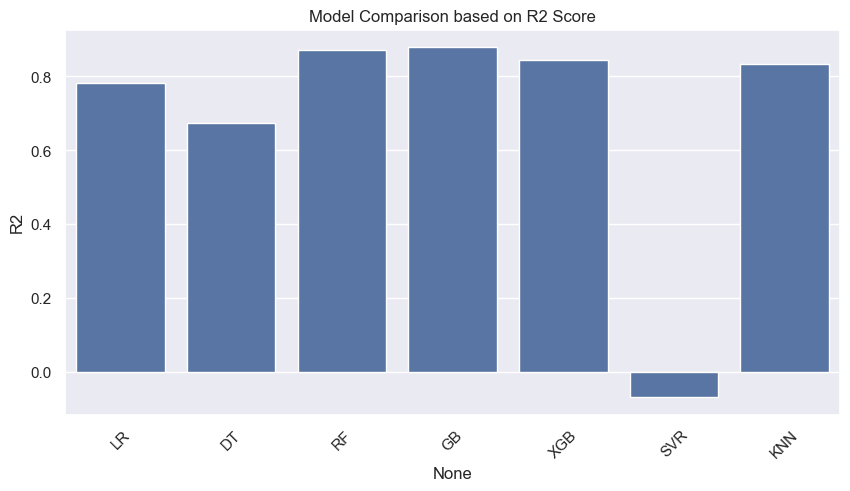

In [195]:
plt.figure(figsize=(10,5))
sns.barplot(x=result_df.index,y=result_df['R2'])
plt.title("Model Comparison based on R2 Score")
plt.xticks(rotation=45)
plt.show()

In [196]:
gradient_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gradient_model.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [200]:
import pickle
pickle.dump(gradient_model, open('model.pkl', 'wb'))
pickle.dump(sr, open('scaler.pkl', 'wb'))

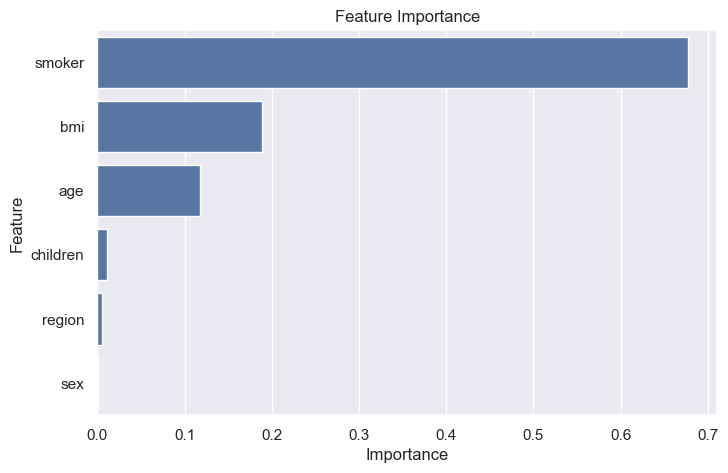

In [202]:
imp = gradient_model.feature_importances_
feature_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': imp
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")
plt.show()